# ObservationBase Testing

Test that the Observation class in SBI4atmret loads CSV files correctly
and produces the same results as the old `load_observations()` from WISEJ1738.

In [1]:
import os
os.environ['pRT_input_data_path'] = '/media/mvasist/Elements/PhDprojects/scratch/input_data_v2.4.9/input_data'

import sys
sys.path.insert(0, '/home/mvasist/Documents/SBI4atmret')
sys.path.insert(0, '/home/mvasist/Documents/WISEJ1738/sbi_ear')

import numpy as np
import yaml
import matplotlib.pyplot as plt

from sbi4atmret.config.configs import BaseConfig
from sbi4atmret.observations.ObservationBase import Observation

## 1. Load via OLD code (WISEJ1738)

In [2]:
from code2explore.observations import load_observations

obs_wlen_miri, obs_miri, sigmaM, \
    obs_wlen_gemini, obs_gemini, sigmaG, \
    obs_wlen_hst, obs_hst, sigmaH, \
    wlength_gm, wlength_hm, \
    x_star_g, x_star_h = load_observations()

print(f"OLD code:")
print(f"  MIRI:   {len(obs_wlen_miri)} points, wlen=[{obs_wlen_miri.min():.3f}, {obs_wlen_miri.max():.3f}]")
print(f"  HST:    {len(obs_wlen_hst)} points, wlen=[{obs_wlen_hst.min():.3f}, {obs_wlen_hst.max():.3f}]")
print(f"  Gemini: {len(obs_wlen_gemini)} points, wlen=[{obs_wlen_gemini.min():.3f}, {obs_wlen_gemini.max():.3f}]")
print(f"  sigmaM: {sigmaM[:3]}...")
print(f"  sigmaH: {sigmaH[:3]}...")
print(f"  sigmaG: {sigmaG[:3]}...")

OLD code:
  MIRI:   1298 points, wlen=[4.910, 17.961]
  HST:    129 points, wlen=[1.103, 1.698]
  Gemini: 305 points, wlen=[1.005, 2.165]
  sigmaM: [5.36364802e-06 5.15723256e-06 5.34782242e-06]...
  sigmaH: [7.19835906e-07 6.28435900e-07 5.64853893e-07]...
  sigmaG: [6.20296084e-06 8.05457762e-06 1.06774556e-05]...


## 2. Load via NEW code (ObservationBase)

In [3]:
config_path = '/home/mvasist/Documents/SBI4atmret/experiments/config_MiriGeminiHST_cloudfree.yaml'
with open(config_path) as f:
    config = BaseConfig(**yaml.safe_load(f))

print(f"Config loaded")
print(f"  Instruments: {list(config.observation_config.instruments.keys())}")
for inst, cfg in config.observation_config.instruments.items():
    print(f"    {inst}: {cfg.path}")

Config loaded
  Instruments: ['hst', 'gemini', 'miri']
    hst: /home/mvasist/Documents/testing/observations/WISEJ1738/hst/spectrum.csv
    gemini: /home/mvasist/Documents/testing/observations/WISEJ1738/gemini/spectrum.csv
    miri: /home/mvasist/Documents/testing/observations/WISEJ1738/miri/spectrum.csv


In [4]:
# Check if the CSV files exist
from pathlib import Path

for inst, cfg in config.observation_config.instruments.items():
    p = Path(cfg.path)
    exists = p.exists()
    print(f"  {inst}: {cfg.path} — {'EXISTS' if exists else 'MISSING'}")
    if exists:
        import pandas as pd
        df = pd.read_csv(p, header=0)
        print(f"    Columns: {list(df.columns)}")
        print(f"    Shape: {df.shape}")
        print(f"    First row: {df.iloc[0].values}")

  hst: /home/mvasist/Documents/testing/observations/WISEJ1738/hst/spectrum.csv — EXISTS
    Columns: ['wavelength[um]', 'flux[Jy]', 'error[Jy]']
    Shape: (129, 3)
    First row: [1.10300000e+00 2.96370096e-01 7.19835906e-07]
  gemini: /home/mvasist/Documents/testing/observations/WISEJ1738/gemini/spectrum.csv — EXISTS
    Columns: ['wavelength[um]', 'flux[Jy]', 'error[Jy]']
    Shape: (305, 3)
    First row: [1.00523763e+00 6.10380326e-01 6.20296084e-06]
  miri: /home/mvasist/Documents/testing/observations/WISEJ1738/miri/spectrum.csv — EXISTS
    Columns: ['wavelength[um]', 'flux[Jy]', 'error[Jy]']
    Shape: (1298, 3)
    First row: [4.90975460e+00 1.65368428e+01 5.36364802e-06]


In [5]:
# Try to instantiate Observation
try:
    obs = Observation(
        observation_config=config.observation_config,
        dataset_config=config.dataset_config,
        simulator_config=config.simulator_config,
    )
    print("Observation loaded successfully!")
    print(f"  instrument_metadata keys: {list(obs.instrument_metadata.keys())}")
    for inst, data in obs.instrument_metadata.items():
        print(f"    {inst}: wlen={len(data['wlen'])}, sigma={len(data['sigma'])}")
except Exception as e:
    print(f"FAILED: {type(e).__name__}: {e}")
    import traceback
    traceback.print_exc()

Observation loaded successfully!
  instrument_metadata keys: ['hst', 'gemini', 'miri']
    hst: wlen=129, sigma=129
    gemini: wlen=305, sigma=305
    miri: wlen=1298, sigma=1298


## 3. Compare OLD vs NEW

In [6]:
# Compare wavelengths
new_wlen_miri = obs.instrument_metadata['miri']['wlen']
new_wlen_hst = obs.instrument_metadata['hst']['wlen']
new_wlen_gemini = obs.instrument_metadata['gemini']['wlen']

print("Wavelength comparison:")
print(f"  MIRI  — old: {obs_wlen_miri.shape}, new: {new_wlen_miri.shape}")
print(f"  HST   — old: {obs_wlen_hst.shape}, new: {new_wlen_hst.shape}")
print(f"  Gemini— old: {obs_wlen_gemini.shape}, new: {new_wlen_gemini.shape}")

if new_wlen_miri.shape == obs_wlen_miri.shape:
    print(f"  MIRI  max diff: {np.max(np.abs(new_wlen_miri - obs_wlen_miri)):.2e}")
if new_wlen_hst.shape == obs_wlen_hst.shape:
    print(f"  HST   max diff: {np.max(np.abs(new_wlen_hst - obs_wlen_hst)):.2e}")
if new_wlen_gemini.shape == obs_wlen_gemini.shape:
    print(f"  Gemini max diff: {np.max(np.abs(new_wlen_gemini - obs_wlen_gemini)):.2e}")

Wavelength comparison:
  MIRI  — old: (1298,), new: (1298,)
  HST   — old: (129,), new: (129,)
  Gemini— old: (305,), new: (305,)
  MIRI  max diff: 0.00e+00
  HST   max diff: 0.00e+00
  Gemini max diff: 0.00e+00


In [7]:
# Compare sigmas
new_sigma_miri = obs.instrument_metadata['miri']['sigma']
new_sigma_hst = obs.instrument_metadata['hst']['sigma']
new_sigma_gemini = obs.instrument_metadata['gemini']['sigma']

print("Sigma comparison:")
print(f"  MIRI  — old: {sigmaM[:3]}, new: {new_sigma_miri[:3]}")
print(f"  HST   — old: {sigmaH[:3]}, new: {new_sigma_hst[:3]}")
print(f"  Gemini— old: {sigmaG[:3]}, new: {new_sigma_gemini[:3]}")

Sigma comparison:
  MIRI  — old: [5.36364802e-06 5.15723256e-06 5.34782242e-06], new: [5.36364802e-06 5.15723256e-06 5.34782242e-06]
  HST   — old: [7.19835906e-07 6.28435900e-07 5.64853893e-07], new: [7.19835906e-07 6.28435900e-07 5.64853893e-07]
  Gemini— old: [6.20296084e-06 8.05457762e-06 1.06774556e-05], new: [6.20296084e-06 8.05457762e-06 1.06774556e-05]


In [8]:
# Compare flux (observation_dict)
if hasattr(obs, 'observation_dict'):
    new_flux_miri = obs.observation_dict['miri']['flux']
    new_flux_hst = obs.observation_dict['hst']['flux']
    new_flux_gemini = obs.observation_dict['gemini']['flux']

    print("Flux comparison:")
    print(f"  MIRI  — old: {obs_miri[:3]}, new: {new_flux_miri[:3]}")
    print(f"  HST   — old: {obs_hst[:3]}, new: {new_flux_hst[:3]}")
    print(f"  Gemini— old: {obs_gemini[:3]}, new: {new_flux_gemini[:3]}")

Flux comparison:
  MIRI  — old: [16.53684276 21.69357606 16.6140608 ], new: [18.96251106 31.02649112 23.95646886]
  HST   — old: [0.2963701 0.2217154 0.151931 ], new: [0.18098297 0.08788215 0.0316811 ]
  Gemini— old: [0.61038033 0.54679486 0.61044458], new: [0.17004749 0.17798596 0.20063932]


## 4. Plot comparison

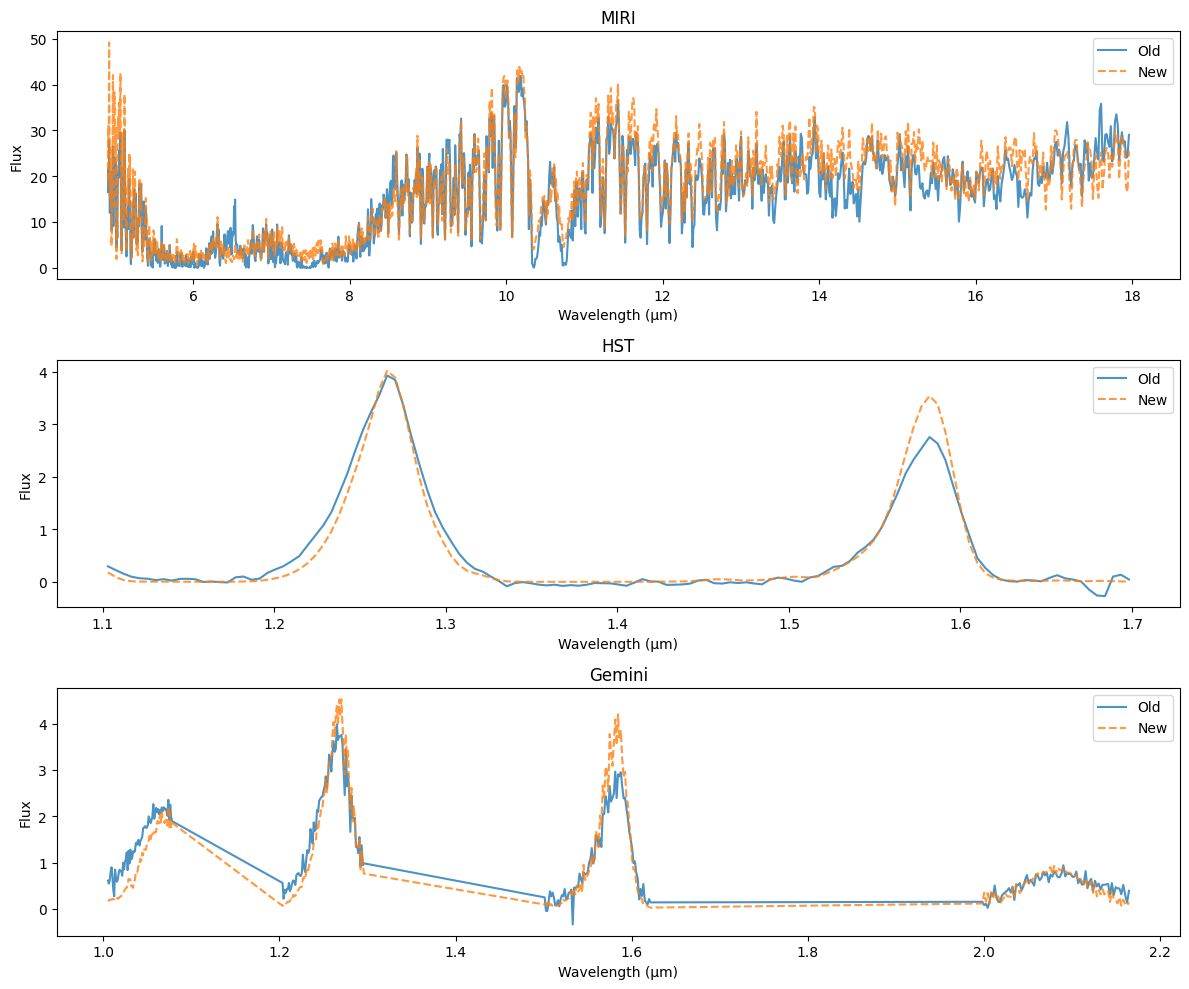

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# MIRI
axes[0].plot(obs_wlen_miri, obs_miri, label='Old', alpha=0.8)
if hasattr(obs, 'observation_dict'):
    axes[0].plot(new_wlen_miri, new_flux_miri, '--', label='New', alpha=0.8)
axes[0].set_title('MIRI')
axes[0].legend()

# HST
axes[1].plot(obs_wlen_hst, obs_hst, label='Old', alpha=0.8)
if hasattr(obs, 'observation_dict'):
    axes[1].plot(new_wlen_hst, new_flux_hst, '--', label='New', alpha=0.8)
axes[1].set_title('HST')
axes[1].legend()

# Gemini
axes[2].plot(obs_wlen_gemini, obs_gemini, label='Old', alpha=0.8)
if hasattr(obs, 'observation_dict'):
    axes[2].plot(new_wlen_gemini, new_flux_gemini, '--', label='New', alpha=0.8)
axes[2].set_title('Gemini')
axes[2].legend()

for ax in axes:
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Flux')

plt.tight_layout()
plt.show()

## 5. Check full_observation (merged + sorted)

In [10]:
# The old code's x_star equivalent
obs_wlen_inst = np.append(obs_wlen_hst, obs_wlen_gemini)
index_argsort = np.argsort(obs_wlen_inst)
obs_inst = np.append(obs_hst, obs_gemini)[index_argsort]
x_star_old = np.append(obs_inst, obs_miri)

print(f"Old x_star shape: {x_star_old.shape}")

if hasattr(obs, 'full_observation'):
    print(f"New full_observation shape: {obs.full_observation.shape}")
    
    if x_star_old.shape == obs.full_observation.shape:
        diff = np.max(np.abs(x_star_old - obs.full_observation))
        print(f"Max difference: {diff:.2e}")
        if diff < 1e-10:
            print("✅ MATCH — ObservationBase produces identical results")
        else:
            print("❌ MISMATCH — investigate scaling or ordering")
    else:
        print("❌ Different shapes — check instrument ordering or concatenation")

Old x_star shape: (1732,)
New full_observation shape: (1732,)
Max difference: 2.13e+01
❌ MISMATCH — investigate scaling or ordering
